In [1]:
import pandas as pd
df = pd.read_csv("IDS_ALLCountries_Data.csv", encoding='latin1')
print(df.head())

  Country Name Country Code Counterpart-Area Name Counterpart-Area Code  \
0  Afghanistan   AFG                        World                   WLD   
1  Afghanistan   AFG                        World                   WLD   
2  Afghanistan   AFG                        World                   WLD   
3  Afghanistan   AFG                        World                   WLD   
4  Afghanistan   AFG                        World                   WLD   

                                         Series Name  Series Code  2000  2001  \
0  Average grace period on new external debt comm...  DT.GPA.DPPG   NaN   NaN   
1  Average grace period on new external debt comm...  DT.GPA.OFFT   NaN   NaN   
2  Average grace period on new external debt comm...  DT.GPA.PRVT   NaN   NaN   
3  Average grant element on new external debt com...  DT.GRE.DPPG   NaN   NaN   
4  Average grant element on new external debt com...  DT.GRE.OFFT   NaN   NaN   

   2002  2003  ...  2023  2024  2025  2026  2027  2028  2029  

In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 62983 entries, 0 to 62982
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country Name           62980 non-null  str    
 1   Country Code           62978 non-null  str    
 2   Counterpart-Area Name  62978 non-null  str    
 3   Counterpart-Area Code  62978 non-null  str    
 4   Series Name            62978 non-null  str    
 5   Series Code            62978 non-null  str    
 6   2000                   49490 non-null  float64
 7   2001                   49434 non-null  float64
 8   2002                   49262 non-null  float64
 9   2003                   49001 non-null  float64
 10  2004                   49195 non-null  float64
 11  2005                   49137 non-null  float64
 12  2006                   49394 non-null  float64
 13  2007                   49645 non-null  float64
 14  2008                   49497 non-null  float64
 15  2009         

In [3]:
df.shape

(62983, 39)

In [4]:
df.columns

Index(['Country Name', 'Country Code', 'Counterpart-Area Name',
       'Counterpart-Area Code', 'Series Name', 'Series Code', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028',
       '2029', '2030', '2031', '2032'],
      dtype='str')

In [5]:
# Find year columns
year_cols=[col for col in df.columns if col.isdigit()]
print(year_cols)

['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028', '2029', '2030', '2031', '2032']


In [6]:
#Convert Wide → Long or columns to rows
df_long = pd.melt(
    df,
    id_vars=[
        'Country Name',
        'Country Code',
        'Series Name',
        'Series Code'
    ],
    value_vars=year_cols,
    var_name='Year',
    value_name='Debt_Value'
)

In [7]:
df_long.head()

,Country Name,Country Code,Series Name,Series Code,Year,Debt_Value
0,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.DPPG,2000,NaN
1,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.OFFT,2000,NaN
2,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.PRVT,2000,NaN
3,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.DPPG,2000,NaN
4,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.OFFT,2000,NaN


In [8]:
df_long.shape


(2078439, 6)

In [9]:
df_long['Debt_Value'].sum()
df_long.groupby(
    'Country Name'
)['Debt_Value'].sum().sort_values(
    ascending=False
).head(10)

Country Name
Low & middle income                                  2.440244e+15
Middle income                                        2.370283e+15
Upper middle income                                  1.736241e+15
East Asia & Pacific (excluding high income)          9.033344e+14
Lower middle income                                  6.340243e+14
China                                                6.217578e+14
Latin America & Caribbean (excluding high income)    5.919362e+14
IDA total                                            3.081156e+14
Europe & Central Asia (excluding high income)        2.690341e+14
South Asia                                           2.419735e+14
Name: Debt_Value, dtype: float64

In [10]:
# Display Duplicates
duplicate_count = df_long.duplicated().sum()
print("Total Duplicate Rows:", duplicate_count)


Total Duplicate Rows: 66


In [11]:
# View duplicate rows
duplicates = df_long[df_long.duplicated()]
duplicates.head()

,Country Name,Country Code,Series Name,Series Code,Year,Debt_Value
62979,NaN,NaN,NaN,NaN,2000,NaN
62980,NaN,NaN,NaN,NaN,2000,NaN
125962,NaN,NaN,NaN,NaN,2001,NaN
125963,NaN,NaN,NaN,NaN,2001,NaN
188945,NaN,NaN,NaN,NaN,2002,NaN


In [12]:
#remove duplicates
df_long=df_long.drop_duplicates()

In [13]:

df_long = df_long.dropna(subset=['Country Name', 'Country Code'])

In [14]:
df_long['Debt_Value'].isnull().sum()

np.int64(733228)

In [15]:
df_long.head()

,Country Name,Country Code,Series Name,Series Code,Year,Debt_Value
0,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.DPPG,2000,NaN
1,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.OFFT,2000,NaN
2,Afghanistan,AFG,Average grace period on new external debt comm...,DT.GPA.PRVT,2000,NaN
3,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.DPPG,2000,NaN
4,Afghanistan,AFG,Average grant element on new external debt com...,DT.GRE.OFFT,2000,NaN


In [16]:
df_long.isnull().sum()

Country Name         0
Country Code         0
Series Name          0
Series Code          0
Year                 0
Debt_Value      733228
dtype: int64

In [17]:
df_long = df_long.dropna(subset=['Debt_Value'])

In [18]:
df_long.to_csv(
    "Cleaned_International_Debt.csv",
    index=False
)

In [19]:
print(df_long.duplicated().sum())

0


In [20]:
country_debt = (
    df_long.groupby('Country Name')['Debt_Value']
    .sum()
    .sort_values(ascending=False)
)

country_debt.head(10)

Country Name
Low & middle income                                  2.440244e+15
Middle income                                        2.370283e+15
Upper middle income                                  1.736241e+15
East Asia & Pacific (excluding high income)          9.033344e+14
Lower middle income                                  6.340243e+14
China                                                6.217578e+14
Latin America & Caribbean (excluding high income)    5.919362e+14
IDA total                                            3.081156e+14
Europe & Central Asia (excluding high income)        2.690341e+14
South Asia                                           2.419735e+14
Name: Debt_Value, dtype: float64

In [21]:
indicator_debt = (
    df_long.groupby('Series Name')['Debt_Value']
    .sum()
    .sort_values(ascending=False)
)

indicator_debt.head(10)

Series Name
GNI (current US$)                                                                2.634973e+15
Imports of goods, services and primary income (current US$)                      7.173482e+14
Exports of goods, services and primary income (current US$)                      6.729154e+14
External debt stocks, total (DOD, current US$)                                   6.569861e+14
Total reserves (includes gold, current US$)                                      5.483682e+14
External debt stocks, long-term (DOD, current US$)                               4.725628e+14
External debt stocks, variable rate (DOD, current US$)                           2.865693e+14
External debt stocks, public and publicly guaranteed (PPG) (DOD, current US$)    2.664304e+14
External debt stocks, long-term public sector (DOD, current US$)                 2.656002e+14
External debt stocks, public sector (PPG) (DOD, current US$)                     2.655288e+14
Name: Debt_Value, dtype: float64

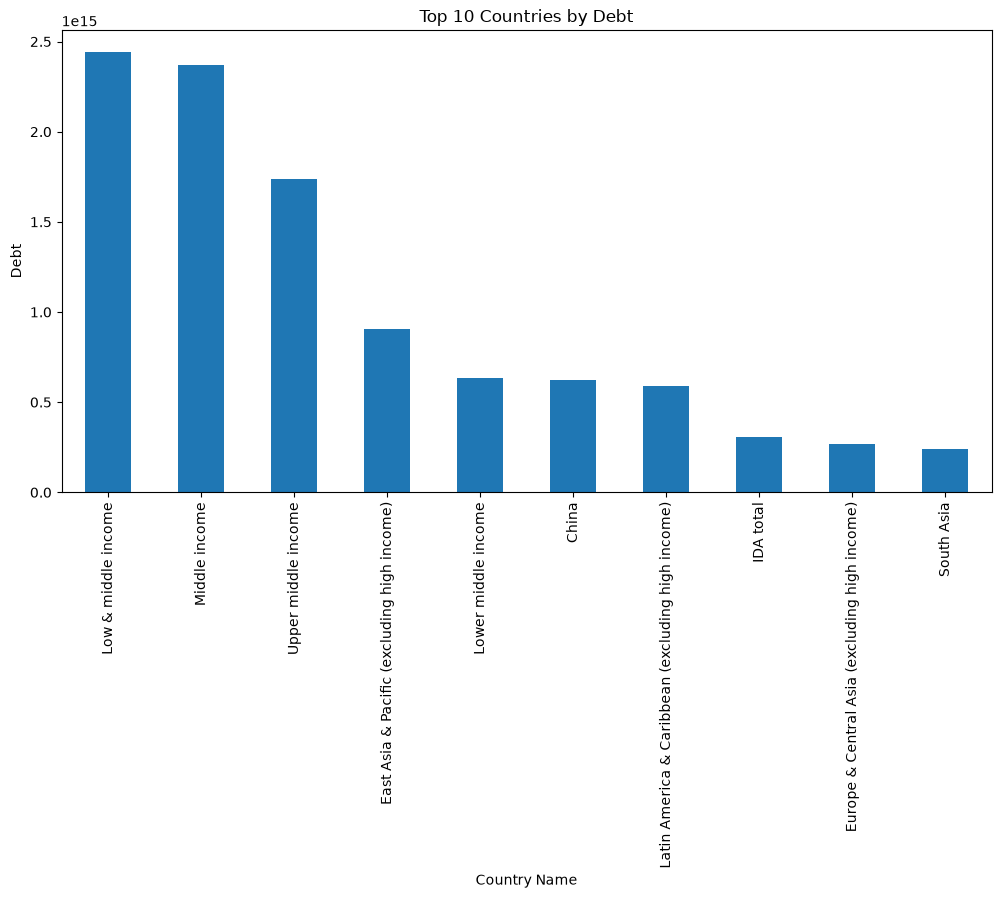

In [22]:
# Top 10 countries
import matplotlib.pyplot as plt

country_debt.head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Top 10 Countries by Debt")
plt.ylabel("Debt")
plt.show()

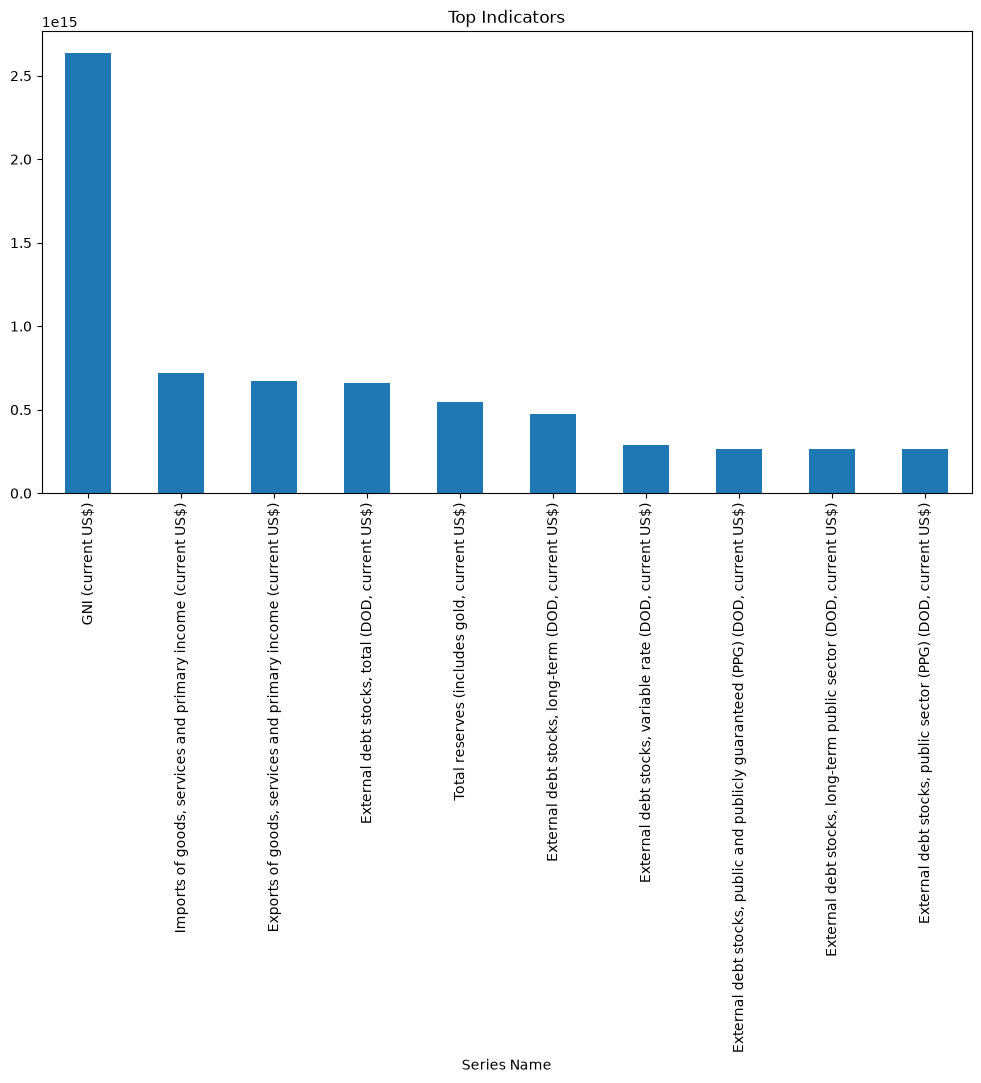

In [23]:
# top 10 indicators
indicator_debt.head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Top Indicators")
plt.show()

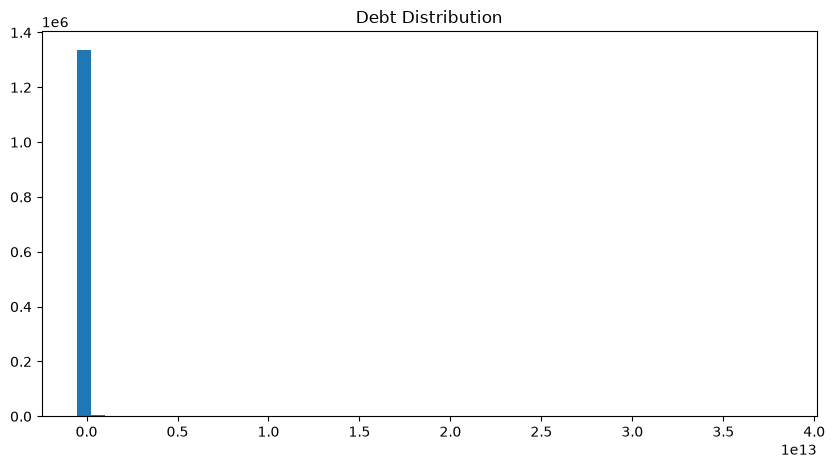

In [24]:
plt.figure(figsize=(10,5))

plt.hist(df_long['Debt_Value'], bins=50)

plt.title("Debt Distribution")

plt.show()

In [25]:
debt_by_year = (
    df_long.groupby('Year')['Debt_Value']
    .sum()
    .reset_index()
)

print(debt_by_year)

    Year    Debt_Value
0   2000  1.797484e+14
1   2001  1.774490e+14
2   2002  1.802866e+14
3   2003  2.013832e+14
4   2004  2.231704e+14
5   2005  2.328355e+14
6   2006  2.563743e+14
7   2007  3.069339e+14
8   2008  3.342473e+14
9   2009  3.408698e+14
10  2010  4.148549e+14
11  2011  4.675905e+14
12  2012  5.097378e+14
13  2013  5.534643e+14
14  2014  5.965354e+14
15  2015  5.506360e+14
16  2016  5.879671e+14
17  2017  6.737300e+14
18  2018  7.027064e+14
19  2019  7.252568e+14
20  2020  7.457741e+14
21  2021  8.321843e+14
22  2022  8.040003e+14
23  2023  8.353925e+14
24  2024  8.785052e+14
25  2025  8.109268e+13
26  2026  7.109083e+13
27  2027  6.543248e+13
28  2028  5.979514e+13
29  2029  4.958922e+13
30  2030  6.152522e+13
31  2031  3.816266e+13
32  2032  3.130134e+13


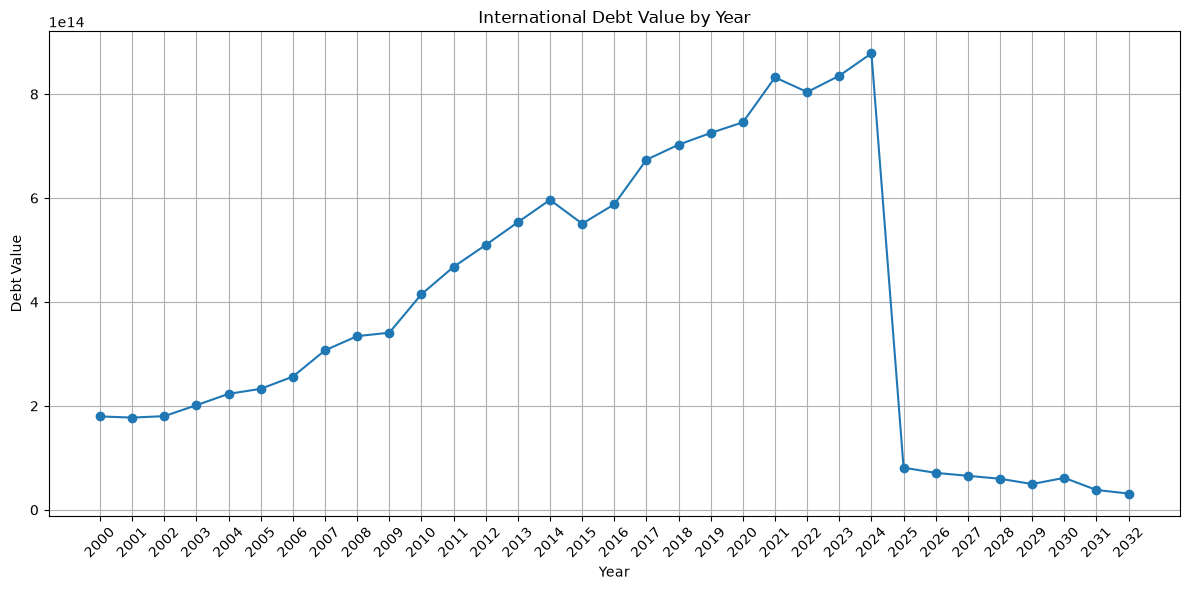

In [26]:
import matplotlib.pyplot as plt

debt_by_year = (
    df_long.groupby('Year')['Debt_Value']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    debt_by_year['Year'],
    debt_by_year['Debt_Value'],
    marker='o'
)

plt.title('International Debt Value by Year')
plt.xlabel('Year')
plt.ylabel('Debt Value')

plt.xticks(debt_by_year['Year'], rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd
df = pd.read_csv("Country-Series - Metadata.csv",encoding='latin1')

In [28]:
# Create Country Name and Country Code columns
df[['Country Name', 'Country Code New']] = (
    df['Country Code']
      .str.extract(r'^(.*?)\s*\((.*?)\)$')
)

In [29]:
df.head()

,Type,Country Code,Series Code,Description,Country Name,Country Code New
0,Country-Series,Afghanistan (AFG),"Foreign direct investment, net inflows in repo...",Data on Foreign Direct Investment are based on...,Afghanistan,AFG
1,Country-Series,Afghanistan (AFG),"Population, total (SP.POP.TOTL)",Data source: United Nations World Population P...,Afghanistan,AFG
2,Country-Series,Afghanistan (AFG),"External debt stocks, total (DOD, current US$)...","Long-term public and publicly guaranteed, long...",Afghanistan,AFG
3,Country-Series,Angola (AGO),"External debt stocks, total (DOD, current US$)...",Long-term public and publicly guaranteed debt ...,Angola,AGO
4,Country-Series,Angola (AGO),"Population, total (SP.POP.TOTL)",Data source: United Nations World Population P...,Angola,AGO


In [30]:
df.drop(columns=['Country Code'], inplace=True)



In [31]:
df.rename(columns={'Country Code New': 'Country Code'}, inplace=True)

In [32]:
df.to_csv(
    "Cleaned_Countries.csv",
    index=False
)

In [33]:
df = pd.read_csv("IDS_CountryMetaData.csv",encoding='latin1')

In [34]:
df = df.dropna(subset=['Region'])

In [35]:
df["Region"].isnull().sum()

np.int64(0)

In [36]:
df.to_csv(
    "Cleaned_Countries_Metadata.csv",
    index=False
)

In [37]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Nimalan@123",
    database="international_debt",
    port=3306
)

cursor = conn.cursor()

print("Connected:", conn.is_connected())

Connected: True


In [38]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS debt_data (
    id INT AUTO_INCREMENT PRIMARY KEY,
    country_name VARCHAR(100),
    country_code VARCHAR(10),
    series_name VARCHAR(255),
    series_code VARCHAR(100),
    year VARCHAR(50),
    debt_value DOUBLE
)
""")

conn.commit()

print("Table ready")

Table ready


In [39]:
cursor.execute("SELECT COUNT(*) FROM debt_data")
print(cursor.fetchone()[0])

1350046


In [40]:
import pandas as pd

sql = """
INSERT INTO debt_data
(country_name, country_code, series_name, series_code, year, debt_value)
VALUES (%s, %s, %s, %s, %s, %s)
"""

batch_size = 5000

for start in range(0, len(df_long), batch_size):

    end = start + batch_size

    batch = df_long.iloc[start:end]

    data = list(
        batch[
            [
                'Country Name',
                'Country Code',
                'Series Name',
                'Series Code',
                'Year',
                'Debt_Value'
            ]
        ].itertuples(index=False, name=None)
    )

    cursor.executemany(sql, data)

    conn.commit()

    print(f"Imported {min(end, len(df_long)):,} / {len(df_long):,} rows")

print("Import Completed Successfully!")

Imported 5,000 / 1,345,046 rows
Imported 10,000 / 1,345,046 rows
Imported 15,000 / 1,345,046 rows
Imported 20,000 / 1,345,046 rows
Imported 25,000 / 1,345,046 rows
Imported 30,000 / 1,345,046 rows
Imported 35,000 / 1,345,046 rows
Imported 40,000 / 1,345,046 rows
Imported 45,000 / 1,345,046 rows
Imported 50,000 / 1,345,046 rows
Imported 55,000 / 1,345,046 rows
Imported 60,000 / 1,345,046 rows
Imported 65,000 / 1,345,046 rows
Imported 70,000 / 1,345,046 rows
Imported 75,000 / 1,345,046 rows
Imported 80,000 / 1,345,046 rows
Imported 85,000 / 1,345,046 rows
Imported 90,000 / 1,345,046 rows
Imported 95,000 / 1,345,046 rows
Imported 100,000 / 1,345,046 rows
Imported 105,000 / 1,345,046 rows
Imported 110,000 / 1,345,046 rows
Imported 115,000 / 1,345,046 rows
Imported 120,000 / 1,345,046 rows
Imported 125,000 / 1,345,046 rows
Imported 130,000 / 1,345,046 rows
Imported 135,000 / 1,345,046 rows
Imported 140,000 / 1,345,046 rows
Imported 145,000 / 1,345,046 rows
Imported 150,000 / 1,345,046 rows
